In [37]:
import os
import numpy as np
import pandas as pd
from blur_detector_torch import BlurDetector
from matplotlib import pyplot as plt

import image_grid

In [3]:
blur_detector = BlurDetector("models/blur_detection_resnet101_final.pth")

已加载模型: models/blur_detection_resnet101_final.pth


In [19]:
root_dir = "/media/filming/2025-白海豚/20240824_JM_01"

In [44]:
fin_dataset = pd.read_csv(
    "/media/filming/2025-白海豚/20240824_JM_01/FIN_METAINFO.csv", index_col=0)

In [45]:
ret = blur_detector.predict("/home/hf/working/中华白海豚/mydata/20240824_JM_01/%s"%fin_dataset.path[1])

In [46]:
ret

{'class': 'clear',
 'class_idx': 0,
 'confidence': 0.6715803146362305,
 'probabilities': {'clear': 0.6715803146362305, 'blur': 0.32841968536376953}}

In [47]:
fin_dataset

,img_id,path,x_min,x_max,y_min,y_max,orig_img,crop_conf,orig_img_h,orig_img_w
0,0,FIN/1214_20240824JM01ZRA11214_FIN00.JPG,3403,4110,2776,3200,1214_20240824JM01ZRA11214.JPG,0.669546,5760,8640
1,1,FIN/1215_20240824JM01ZRA11215_FIN00.JPG,3597,4297,2754,3204,1215_20240824JM01ZRA11215.JPG,0.804073,5760,8640
2,2,FIN/1216_20240824JM01ZRA11216_FIN00.JPG,3695,4441,2774,3226,1216_20240824JM01ZRA11216.JPG,0.791573,5760,8640
3,3,FIN/1217_20240824JM01ZRA11217_FIN00.JPG,3711,4453,2796,3238,1217_20240824JM01ZRA11217.JPG,0.824041,5760,8640
4,4,FIN/1218_20240824JM01ZRA11218_FIN00.JPG,3731,4435,2806,3239,1218_20240824JM01ZRA11218.JPG,0.831123,5760,8640
...,...,...,...,...,...,...,...,...,...,...
2622,2622,FIN/0043_20240824JM01ZRA10043_FIN00.JPG,2214,2427,1591,1711,0043_20240824JM01ZRA10043.JPG,0.779053,2880,4320
2623,2623,FIN/0044_20240824JM01ZRA10044_FIN00.JPG,2192,2423,1561,1688,0044_20240824JM01ZRA10044.JPG,0.813805,2880,4320
2624,2624,FIN/0045_20240824JM01ZRA10045_FIN00.JPG,2170,2434,1533,1677,0045_20240824JM01ZRA10045.JPG,0.835904,2880,4320
2625,2625,FIN/0046_20240824JM01ZRA10046_FIN00.JPG,2137,2427,1526,1678,0046_20240824JM01ZRA10046.JPG,0.833445,2880,4320


In [16]:
fin_dataset.path

0       FIN2/1214_20240824JM01ZRA11214_fin00.JPG
1       FIN2/1215_20240824JM01ZRA11215_fin00.JPG
2       FIN2/1216_20240824JM01ZRA11216_fin00.JPG
3       FIN2/1217_20240824JM01ZRA11217_fin00.JPG
4       FIN2/1218_20240824JM01ZRA11218_fin00.JPG
                          ...                   
2622    FIN2/0043_20240824JM01ZRA10043_fin00.JPG
2623    FIN2/0044_20240824JM01ZRA10044_fin00.JPG
2624    FIN2/0045_20240824JM01ZRA10045_fin00.JPG
2625    FIN2/0046_20240824JM01ZRA10046_fin00.JPG
2626    FIN2/0047_20240824JM01ZRA10047_fin00.JPG
Name: path, Length: 2627, dtype: object

In [48]:
%%time
clearness_list = []
clear_list = []
for i in fin_dataset.path:
    ret = blur_detector.predict( root_dir + "/" + i)
    clearness_list.append( ret['probabilities']['clear'] )
    clear_list.append(ret['class'] == 'clear')

CPU times: user 11min 29s, sys: 1.68 s, total: 11min 31s
Wall time: 1min 32s


In [49]:
fin_dataset["clearness"] = clearness_list

In [50]:
fin_dataset

,img_id,path,x_min,x_max,y_min,y_max,orig_img,crop_conf,orig_img_h,orig_img_w,clearness
0,0,FIN/1214_20240824JM01ZRA11214_FIN00.JPG,3403,4110,2776,3200,1214_20240824JM01ZRA11214.JPG,0.669546,5760,8640,0.316150
1,1,FIN/1215_20240824JM01ZRA11215_FIN00.JPG,3597,4297,2754,3204,1215_20240824JM01ZRA11215.JPG,0.804073,5760,8640,0.671580
2,2,FIN/1216_20240824JM01ZRA11216_FIN00.JPG,3695,4441,2774,3226,1216_20240824JM01ZRA11216.JPG,0.791573,5760,8640,0.709832
3,3,FIN/1217_20240824JM01ZRA11217_FIN00.JPG,3711,4453,2796,3238,1217_20240824JM01ZRA11217.JPG,0.824041,5760,8640,0.633289
4,4,FIN/1218_20240824JM01ZRA11218_FIN00.JPG,3731,4435,2806,3239,1218_20240824JM01ZRA11218.JPG,0.831123,5760,8640,0.262074
...,...,...,...,...,...,...,...,...,...,...,...
2622,2622,FIN/0043_20240824JM01ZRA10043_FIN00.JPG,2214,2427,1591,1711,0043_20240824JM01ZRA10043.JPG,0.779053,2880,4320,0.000575
2623,2623,FIN/0044_20240824JM01ZRA10044_FIN00.JPG,2192,2423,1561,1688,0044_20240824JM01ZRA10044.JPG,0.813805,2880,4320,0.110677
2624,2624,FIN/0045_20240824JM01ZRA10045_FIN00.JPG,2170,2434,1533,1677,0045_20240824JM01ZRA10045.JPG,0.835904,2880,4320,0.470295
2625,2625,FIN/0046_20240824JM01ZRA10046_FIN00.JPG,2137,2427,1526,1678,0046_20240824JM01ZRA10046.JPG,0.833445,2880,4320,0.618249


In [54]:
fin_dataset.to_csv("/media/filming/2025-白海豚/20240824_JM_01/FIN_METAINFO.csv")

In [52]:
for i in fin_dataset.query('clearness< 0.1')['path']:
    src = root_dir + "/" + i
    dest = root_dir + "/BLUR2/" + i[4:]
    os.symlink(src, dest)

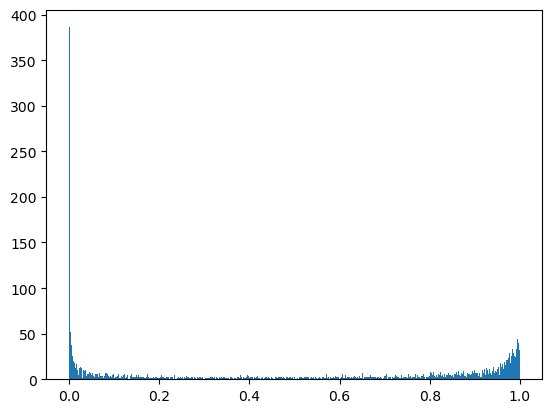

In [53]:
plt.hist(fin_dataset.clearness, bins=512)
plt.show()